In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [2]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [3]:
print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [4]:
annual_return = (
    nav.groupby("amfi_code")["daily_return"]
       .mean()
)

annual_return = ((1 + annual_return) ** 252 - 1) * 100

In [5]:
volatility = (
    nav.groupby("amfi_code")["daily_return"]
       .std()
)

volatility = volatility * np.sqrt(252) * 100

In [6]:
risk_free_rate = 6

sharpe = (
    annual_return - risk_free_rate
) / volatility

In [7]:
def max_drawdown(nav_series):

    rolling_max = nav_series.cummax()

    drawdown = (
        nav_series - rolling_max
    ) / rolling_max

    return drawdown.min() * 100

In [8]:
drawdowns = nav.groupby(
    "amfi_code"
)["nav"].apply(max_drawdown)

In [9]:
metrics = pd.DataFrame({

    "annual_return_pct": annual_return,

    "volatility_pct": volatility,

    "sharpe_ratio": sharpe,

    "max_drawdown_pct": drawdowns

}).reset_index()

In [10]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

metrics = metrics.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

In [11]:
metrics.to_csv(
    "../data/processed/performance_metrics.csv",
    index=False
)

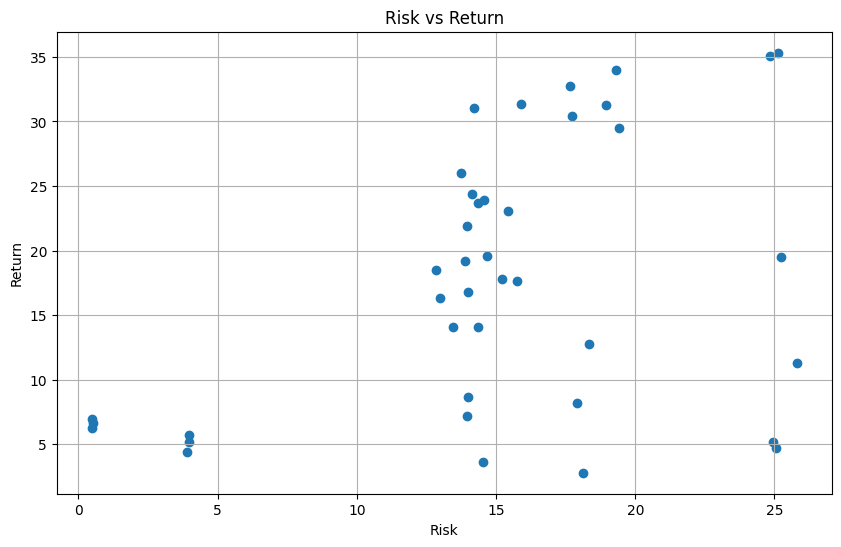

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    metrics["volatility_pct"],
    metrics["annual_return_pct"]
)

plt.xlabel("Risk")
plt.ylabel("Return")

plt.title("Risk vs Return")
plt.grid(True)


plt.show()

In [14]:
top_sharpe = metrics.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

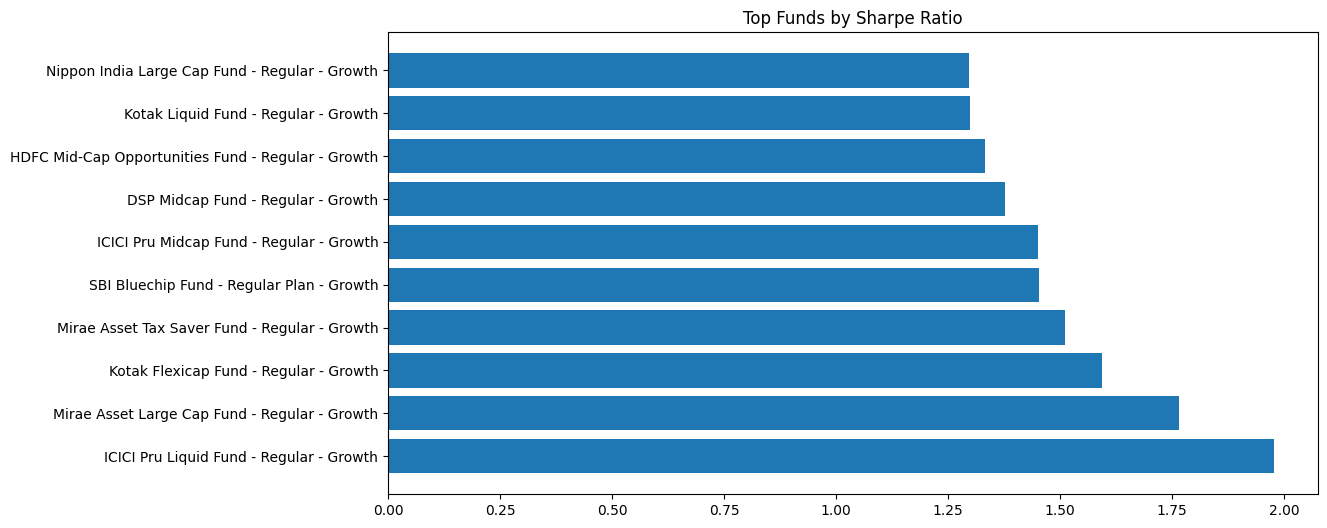

In [16]:
plt.figure(figsize=(12,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.title(
    "Top Funds by Sharpe Ratio"
)



plt.show()

In [17]:
metrics["score"] = (

    metrics["annual_return_pct"] * 0.4 +

    metrics["sharpe_ratio"] * 30 +

    metrics["max_drawdown_pct"] * (-0.1)

)

In [18]:
top_funds = metrics.sort_values(
    "score",
    ascending=False
).head(10)

In [19]:
print(
    top_funds[
        [
            "scheme_name",
            "annual_return_pct",
            "sharpe_ratio",
            "score"
        ]
    ]
)

                                          scheme_name  annual_return_pct  \
34      Mirae Asset Large Cap Fund - Regular - Growth          31.051613   
27           ICICI Pru Liquid Fund - Regular - Growth           6.976545   
30             Kotak Flexicap Fund - Regular - Growth          31.318423   
36      Mirae Asset Tax Saver Fund - Regular - Growth          32.724124   
25           ICICI Pru Midcap Fund - Regular - Growth          33.974986   
19          SBI Bluechip Fund - Regular Plan - Growth          25.976767   
38                 DSP Midcap Fund - Regular - Growth          30.443234   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...          31.253944   
39              DSP Small Cap Fund - Regular - Growth          35.087387   
21         SBI Small Cap Fund - Regular Plan - Growth          35.320299   

    sharpe_ratio      score  
34      1.764980  66.496629  
27      1.977161  62.115214  
30      1.593658  61.634506  
36      1.512058  60.091066  
25      1.450